# Hyper-Parameter-Optimization: Hyper-Tree-AR Example

This notebook demonstrates how to use HPO for the Hyper-Tree-AR model using the Air Passengers dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from hypertrees.models import HyperTreeAR
from metrics import calculate_metrics
import optuna
from optuna.samplers import TPESampler

# General Parameters

In [2]:
lag_p=12                    # Lag order for AR(p) models
freq='MS'                   # Monthly frequency
fcst_h=12                   # Forecast horizon (12 months ahead)
num_iterations=200          # Maximum number of iterations for training
early_stopping_round=10     # Early stopping rounds for HPO (stop if no improvement for 10 rounds)
n_trials=20                 # Number of HPO trials

## Load and Prepare Data

We'll use the Air Passengers dataset which contains monthly airline passenger numbers from 1949 to 1960.

In [3]:
# The data needs to have the following columns: 'date', 'series_id', 'value'. All other columns are automatically treated as features.
# For the AR-models, you don't have to add lag-values yourself, this happens automatically during training.
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.rename(columns={'unique_id': 'series_id', 'ds': 'date', 'y': 'value'}, inplace=True)
df['month'] = df['date'].dt.month
df["quarter"] = df['date'].dt.quarter
test = df.tail(fcst_h)
train = df.drop(test.index)

## Initialize Hyper-Tree-AR

In [4]:
# Initialize the Hyper-Tree-AR model
ht_ar = HyperTreeAR(
    p=lag_p,       # AR order (use last p months)
    freq=freq,     # Frequency
    fcst_h=fcst_h  # Forecast h months ahead
)

## HPO using Optuna

In [5]:
def optuna_objective(trial: optuna.Trial) -> float:

    # Set hyperparameter suggestions. We only use a few hyper-paramters here, but you can add more.
    hpo_params = {
        "max_depth": trial.suggest_categorical("max_depth", [-1] + list(range(1, 11))),
    }

    # Train with eval mode: the train data is split into training and validation internally, with the last fcst_h observations used for validation.
    # So there is no time-series cross-validation here, only the last fcst_h points are used for evaluation.
    hpo_model = ht_ar.train(
        lgb_params=hpo_params,
        num_iterations=num_iterations,
        train_data=train,
        validation=True,
        early_stopping_round=early_stopping_round,
        seed=123,
        verbose=-1
    )

	# Extract error value for best iteration
    best_iteration = hpo_model.best_iteration
    error_val = hpo_model.validation_metrics["MSELoss"][best_iteration]
    trial.set_user_attr("best_iteration", int(best_iteration))

    return error_val

# Create Optuna study and optimize
sampler = TPESampler()
study = optuna.create_study(sampler=sampler, direction='minimize', study_name="HPO for Hyper-Tree-AR")
study.optimize(optuna_objective, n_trials=n_trials, show_progress_bar=True)

# Optimal parameters and stopping round
opt_param = study.best_trial
opt_param.params["best_iteration"] = int(study.trials_dataframe()["user_attrs_best_iteration"][study.trials_dataframe()["value"].idxmin()])

# Extract parameters and round
opt_params = opt_param.params.copy()
opt_rounds = opt_params["best_iteration"]
del opt_params["best_iteration"]

[I 2026-05-07 10:49:45,363] A new study created in memory with name: HPO for Hyper-Tree-AR


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-07 10:49:45,481] Trial 0 finished with value: 217.9542694091797 and parameters: {'max_depth': 6}. Best is trial 0 with value: 217.9542694091797.
[I 2026-05-07 10:49:46,203] Trial 1 finished with value: 183.57232666015625 and parameters: {'max_depth': 1}. Best is trial 1 with value: 183.57232666015625.
[I 2026-05-07 10:49:46,399] Trial 2 finished with value: 217.9542694091797 and parameters: {'max_depth': 5}. Best is trial 1 with value: 183.57232666015625.
[I 2026-05-07 10:49:46,491] Trial 3 finished with value: 217.9542694091797 and parameters: {'max_depth': 4}. Best is trial 1 with value: 183.57232666015625.
[I 2026-05-07 10:49:46,570] Trial 4 finished with value: 217.9542694091797 and parameters: {'max_depth': 4}. Best is trial 1 with value: 183.57232666015625.
[I 2026-05-07 10:49:46,657] Trial 5 finished with value: 217.9542694091797 and parameters: {'max_depth': 10}. Best is trial 1 with value: 183.57232666015625.
[I 2026-05-07 10:49:46,737] Trial 6 finished with value: 

## Train and Forecast

In [6]:
# Train the model
ht_ar.train(
    lgb_params=opt_params,
    num_iterations=opt_rounds,
    train_data=train,
    seed=123,
    verbose=-1
)

# Create forecasts
ht_ar_fcst = ht_ar.forecast(
    test_data=test,
)

## Plot Results

Let's plot the data and our forecasts.

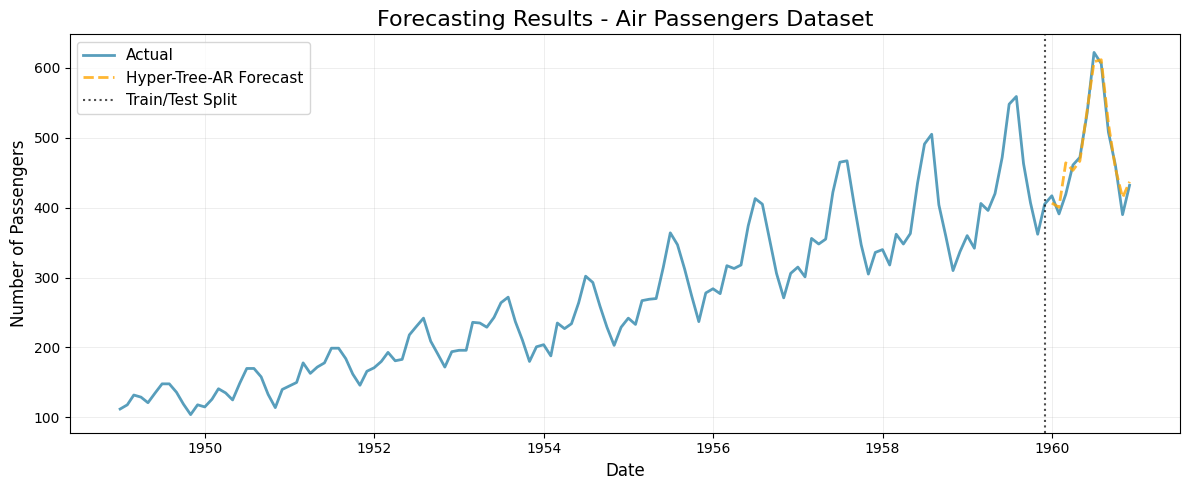

In [7]:
plt.figure(figsize=(12, 5))

datasets = [
        (df, 'date', 'value', 'Actual', '#2E86AB', '-'),
        (ht_ar_fcst, 'date', 'fcst', 'Hyper-Tree-AR Forecast', 'orange', '--'),
    ]

for data, x_col, y_col, label, color, style in datasets:
    plt.plot(data[x_col], data[y_col], label=label, color=color,
            linestyle=style, linewidth=2, alpha=0.8)
split_date = train['date'].max()
plt.axvline(x=split_date, color='black', linestyle=':', alpha=0.7, label='Train/Test Split')

plt.title('Forecasting Results - Air Passengers Dataset', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate Forecast Accuracy

Let's calculate some basic accuracy metrics to evaluate our forecasts.

In [8]:
fcsts_df = ht_ar_fcst.merge(
    test[["date", "value"]],
    on=["date"],
    how="inner"
)

fcsts_df.groupby("model").apply(calculate_metrics).round(3)

,MAE,MAPE,sMAPE,WAPE,RMSE
model,,,,,
Hyper-Tree-AR(12),12.231,2.755,2.694,2.569,16.663
